In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
dataset=pd.read_csv("dataset.csv", index_col=0)
outcome=pd.read_csv("outcome.csv", index_col=0)

In [6]:
dataset.shape
dataset.columns


Index(['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11', 'RNF13', 'GTF2IP1',
       'REM1', 'MTVR2', 'RTN4RL2',
       ...
       'OR51A7', 'WT1', 'RNF24', 'MED15', 'ZIC5', 'MED16', 'HCG27', 'CYP2A13',
       'CCR10', 'KDM4D'],
      dtype='str', length=16383)

In [7]:
outcome.shape
outcome.columns

Index(['BRCA_subtype'], dtype='str')

In [8]:
combined=dataset.join(outcome)

In [9]:
combined.shape
combined.columns

Index(['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11', 'RNF13', 'GTF2IP1',
       'REM1', 'MTVR2', 'RTN4RL2',
       ...
       'WT1', 'RNF24', 'MED15', 'ZIC5', 'MED16', 'HCG27', 'CYP2A13', 'CCR10',
       'KDM4D', 'BRCA_subtype'],
      dtype='str', length=16384)

In [10]:
combined.head(10)

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,WT1,RNF24,MED15,ZIC5,MED16,HCG27,CYP2A13,CCR10,KDM4D,BRCA_subtype
TCGA-AR-A5QQ-01,9.5074,1.5787,0.0000,11.3676,11.1292,9.9722,11.5966,3.2396,0.0000,3.5764,...,3.1616,7.8109,11.6239,4.8736,10.7543,3.2396,0.0000,3.9455,4.9909,NaN
TCGA-D8-A1JA-01,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0000,6.0854,...,0.3459,9.9935,10.3422,5.0067,8.9546,2.4151,0.0000,1.6630,5.7206,Her2
TCGA-BH-A0BQ-01,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0000,5.8329,...,4.3645,8.2866,11.0562,0.0000,10.3913,2.6166,0.0000,4.8579,5.1699,LumA
TCGA-BH-A0BT-01,9.0198,1.3414,0.0000,13.1881,11.0911,10.4244,12.6427,2.7553,0.0000,4.6308,...,5.0536,8.7778,10.4420,0.0000,9.6572,4.0637,1.5447,2.0242,6.1611,LumA
TCGA-A8-A06X-01,9.6417,0.5819,0.0000,12.0036,11.2545,10.1480,12.6622,4.2765,1.8007,4.4505,...,3.8982,7.6201,10.0268,0.0000,9.6684,2.8988,0.0000,3.3135,3.9455,LumB
TCGA-A8-A096-01,9.7665,0.2738,0.8765,11.8118,10.8554,10.4282,12.4810,4.3232,0.0000,5.0156,...,4.6815,7.8086,11.0203,0.0000,10.2189,3.5172,0.0000,2.6380,5.1659,LumB
TCGA-BH-A0C7-01,10.0931,3.6090,0.0000,11.3820,10.7663,10.3366,12.7240,2.2163,0.3340,5.0910,...,5.2575,7.8006,9.9458,6.4553,9.8517,5.1557,0.3340,3.5460,5.1129,LumB
TCGA-AC-A5XU-01,9.1524,0.4738,0.0000,11.5004,10.4358,10.4248,13.7292,5.8810,0.0000,5.9552,...,4.2091,7.6885,10.8724,0.0000,10.6597,5.0895,0.0000,4.7984,3.7063,NaN
TCGA-PE-A5DE-01,9.9398,2.9378,0.0000,12.2055,11.2210,9.8265,12.2089,4.4802,0.0000,5.0818,...,1.4733,8.5386,11.5637,0.0000,10.6175,4.5639,0.0000,4.8790,4.0483,NaN
TCGA-PE-A5DC-01,9.6287,4.1136,0.0000,12.1312,10.8013,10.3031,12.4242,5.9430,1.1939,5.8169,...,1.6536,9.0908,10.6021,3.3845,10.7327,5.7379,0.5152,4.8095,3.8812,NaN


In [15]:
combined_copy= combined.copy()
print(combined.shape) #Wie gross das Dataset ist
print(combined.columns[:10]) #die ersten 10 Spaltennamen
print(combined["BRCA_subtype"].value_counts(dropna=False))#Wie die Subtypen verteilt sind

(1218, 16384)
Index(['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11', 'RNF13', 'GTF2IP1',
       'REM1', 'MTVR2', 'RTN4RL2'],
      dtype='str')
BRCA_subtype
LumA      434
NaN       262
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64


In [16]:
cols=list(combined.columns[:5])+["BRCA_subtype"]
combined[cols].head(10)

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,BRCA_subtype
TCGA-AR-A5QQ-01,9.5074,1.5787,0.0000,11.3676,11.1292,NaN
TCGA-D8-A1JA-01,7.4346,3.6607,0.6245,11.9181,13.5273,Her2
TCGA-BH-A0BQ-01,9.3216,2.7224,0.5526,11.9665,11.4105,LumA
TCGA-BH-A0BT-01,9.0198,1.3414,0.0000,13.1881,11.0911,LumA
TCGA-A8-A06X-01,9.6417,0.5819,0.0000,12.0036,11.2545,LumB
TCGA-A8-A096-01,9.7665,0.2738,0.8765,11.8118,10.8554,LumB
TCGA-BH-A0C7-01,10.0931,3.6090,0.0000,11.3820,10.7663,LumB
TCGA-AC-A5XU-01,9.1524,0.4738,0.0000,11.5004,10.4358,NaN
TCGA-PE-A5DE-01,9.9398,2.9378,0.0000,12.2055,11.2210,NaN
TCGA-PE-A5DC-01,9.6287,4.1136,0.0000,12.1312,10.8013,NaN


In [19]:
combined_small = combined[list(combined.columns[:10]) + ["BRCA_subtype"]].copy()
combined_small.head(10)

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,BRCA_subtype
TCGA-AR-A5QQ-01,9.5074,1.5787,0.0000,11.3676,11.1292,9.9722,11.5966,3.2396,0.0000,3.5764,NaN
TCGA-D8-A1JA-01,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0000,6.0854,Her2
TCGA-BH-A0BQ-01,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0000,5.8329,LumA
TCGA-BH-A0BT-01,9.0198,1.3414,0.0000,13.1881,11.0911,10.4244,12.6427,2.7553,0.0000,4.6308,LumA
TCGA-A8-A06X-01,9.6417,0.5819,0.0000,12.0036,11.2545,10.1480,12.6622,4.2765,1.8007,4.4505,LumB
TCGA-A8-A096-01,9.7665,0.2738,0.8765,11.8118,10.8554,10.4282,12.4810,4.3232,0.0000,5.0156,LumB
TCGA-BH-A0C7-01,10.0931,3.6090,0.0000,11.3820,10.7663,10.3366,12.7240,2.2163,0.3340,5.0910,LumB
TCGA-AC-A5XU-01,9.1524,0.4738,0.0000,11.5004,10.4358,10.4248,13.7292,5.8810,0.0000,5.9552,NaN
TCGA-PE-A5DE-01,9.9398,2.9378,0.0000,12.2055,11.2210,9.8265,12.2089,4.4802,0.0000,5.0818,NaN
TCGA-PE-A5DC-01,9.6287,4.1136,0.0000,12.1312,10.8013,10.3031,12.4242,5.9430,1.1939,5.8169,NaN


In [20]:
cols = ["BRCA_subtype"] + [c for c in combined.columns if c != "BRCA_subtype"]
combined_reordered = combined[cols].copy()
combined_reordered.head()

,BRCA_subtype,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,...,OR51A7,WT1,RNF24,MED15,ZIC5,MED16,HCG27,CYP2A13,CCR10,KDM4D
TCGA-AR-A5QQ-01,NaN,9.5074,1.5787,0.0000,11.3676,11.1292,9.9722,11.5966,3.2396,0.0000,...,0.0,3.1616,7.8109,11.6239,4.8736,10.7543,3.2396,0.0000,3.9455,4.9909
TCGA-D8-A1JA-01,Her2,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0000,...,0.0,0.3459,9.9935,10.3422,5.0067,8.9546,2.4151,0.0000,1.6630,5.7206
TCGA-BH-A0BQ-01,LumA,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0000,...,0.0,4.3645,8.2866,11.0562,0.0000,10.3913,2.6166,0.0000,4.8579,5.1699
TCGA-BH-A0BT-01,LumA,9.0198,1.3414,0.0000,13.1881,11.0911,10.4244,12.6427,2.7553,0.0000,...,0.0,5.0536,8.7778,10.4420,0.0000,9.6572,4.0637,1.5447,2.0242,6.1611
TCGA-A8-A06X-01,LumB,9.6417,0.5819,0.0000,12.0036,11.2545,10.1480,12.6622,4.2765,1.8007,...,0.0,3.8982,7.6201,10.0268,0.0000,9.6684,2.8988,0.0000,3.3135,3.9455


In [21]:
combined_labeled = combined.dropna(subset=["BRCA_subtype"]).copy()

cols = ["BRCA_subtype"] + list(combined_labeled.columns[:10])
combined_small = combined_labeled[cols].copy()

combined_small.head(10)

,BRCA_subtype,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2
TCGA-D8-A1JA-01,Her2,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0000,6.0854
TCGA-BH-A0BQ-01,LumA,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0000,5.8329
TCGA-BH-A0BT-01,LumA,9.0198,1.3414,0.0000,13.1881,11.0911,10.4244,12.6427,2.7553,0.0000,4.6308
TCGA-A8-A06X-01,LumB,9.6417,0.5819,0.0000,12.0036,11.2545,10.1480,12.6622,4.2765,1.8007,4.4505
TCGA-A8-A096-01,LumB,9.7665,0.2738,0.8765,11.8118,10.8554,10.4282,12.4810,4.3232,0.0000,5.0156
TCGA-BH-A0C7-01,LumB,10.0931,3.6090,0.0000,11.3820,10.7663,10.3366,12.7240,2.2163,0.3340,5.0910
TCGA-AR-A0TV-01,LumB,9.6694,0.4330,0.0000,11.9378,11.2889,10.6282,11.7596,3.5666,0.0000,5.8415
TCGA-BH-A18J-01,LumA,9.2718,2.1682,0.4324,12.3127,11.2739,9.9904,12.7352,4.2609,0.0000,4.6703
TCGA-BH-A0W7-01,LumA,9.5610,2.6648,0.0000,11.9861,10.8410,10.0474,12.9301,5.0993,0.0000,6.0062
TCGA-BH-A0HA-01,LumA,9.8078,1.9196,0.0000,12.4059,11.4196,10.4422,12.8427,5.0649,0.0000,4.5686


In [ ]:
"""Für jeden Patienten:

BRCA_subtype
top_gene = das am stärksten exprimierte Gen
top_gene_value = wie stark es exprimiert ist """

combined_labeled = combined.dropna(subset=["BRCA_subtype"]).copy()

gene_cols = [c for c in combined_labeled.columns if c != "BRCA_subtype"]

combined_labeled["top_gene"] = combined_labeled[gene_cols].idxmax(axis=1)
combined_labeled["top_gene_value"] = combined_labeled[gene_cols].max(axis=1)

combined_labeled[["BRCA_subtype", "top_gene", "top_gene_value"]].head(10)

,BRCA_subtype,top_gene,top_gene_value
TCGA-D8-A1JA-01,Her2,FN1,17.3728
TCGA-BH-A0BQ-01,LumA,COL1A1,18.0575
TCGA-BH-A0BT-01,LumA,C4A,17.2425
TCGA-A8-A06X-01,LumB,ACTB,17.0628
TCGA-A8-A096-01,LumB,FN1,17.7716
TCGA-BH-A0C7-01,LumB,COL1A1,17.2607
TCGA-AR-A0TV-01,LumB,YWHAZ,17.0844
TCGA-BH-A18J-01,LumA,C4A,17.9971
TCGA-BH-A0W7-01,LumA,COL1A1,17.4112
TCGA-BH-A0HA-01,LumA,CPB1,19.4432


In [ ]:
#Wie oft kommt welches Top-Gen pro Subtyp vor?
top_gene_counts = pd.crosstab(
    combined_labeled["BRCA_subtype"],
    combined_labeled["top_gene"]
)

top_gene_counts

top_gene,A2M,ABHD2,ACTB,ADH1B,AHNAK,ANPEP,APOD,ATP1A1,AZGP1,B2M,...,SCD,SCGB2A2,SERPINA3,SLC39A6,SMR3B,STC2,TTN,VIM,XBP1,YWHAZ
BRCA_subtype,,,,,,,,,,,,,,,,,,,,,
Basal,2,0,31,0,0,0,0,1,0,3,...,0,0,2,0,2,0,0,0,0,0
Her2,0,0,5,0,0,0,2,0,0,0,...,0,4,0,0,0,0,0,0,0,0
LumA,1,0,11,0,5,0,4,0,1,1,...,2,18,2,12,0,3,1,1,6,0
LumB,0,1,16,0,1,1,1,0,1,3,...,2,3,1,9,0,0,0,0,3,4
Normal,0,0,4,1,21,0,2,0,0,1,...,8,0,0,0,0,0,0,0,0,0


In [24]:
top_gene_counts.sum(axis=0).sort_values(ascending=False).head(10)
#nur die wichtigsten top gene

top_gene
COL1A1     201
FN1        118
EEF1A1     107
ACTB        67
CPB1        44
IGFBP5      39
MGP         33
AHNAK       27
SCGB2A2     25
GAPDH       24
dtype: int64

In [27]:
#Pro subtyp die häufigsten top gene
for subtype in combined_labeled["BRCA_subtype"].unique():
    print(f"\n{subtype}")
    print(
        combined_labeled.loc[combined_labeled["BRCA_subtype"] == subtype, "top_gene"]
        .value_counts()
        .head(10)
    )


Her2
top_gene
FN1         17
ERBB2        9
COL1A1       7
ACTB         5
LOC96610     5
CD24         4
SCGB2A2      4
APOD         2
PABPC1       2
GAPDH        1
Name: count, dtype: int64

LumA
top_gene
COL1A1     147
FN1         50
CPB1        36
EEF1A1      30
IGFBP5      24
SCGB2A2     18
MGP         15
SLC39A6     12
ACTB        11
COL1A2       7
Name: count, dtype: int64

LumB
top_gene
COL1A1     33
FN1        32
ACTB       16
IGFBP5     15
SLC39A6     9
CPB1        8
EEF1A1      7
CD24        5
MGP         5
YWHAZ       4
Name: count, dtype: int64

Basal
top_gene
ACTB        31
GAPDH       20
EEF1A1      18
FN1         16
LOC96610     9
MGP          6
CD74         5
CD24         5
COL1A1       5
LTF          4
Name: count, dtype: int64

Normal
top_gene
EEF1A1    51
AHNAK     21
COL1A1     9
SCD        8
MGP        7
ACTB       4
FN1        3
FTL        2
FOS        2
APOD       2
Name: count, dtype: int64


In [ ]:
#Durchschnittliche Genaktivität pro Subtyp vergleichen, welche Subtypen sich ähneln.
subtype_means = combined_labeled.groupby("BRCA_subtype")[gene_cols].mean()
subtype_means

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,OR51A7,WT1,RNF24,MED15,ZIC5,MED16,HCG27,CYP2A13,CCR10,KDM4D
BRCA_subtype,,,,,,,,,,,,,,,,,,,,,
Basal,9.876565,4.219185,0.314556,11.659515,11.002901,10.437937,12.628220,4.737054,0.370556,5.123986,...,0.000000,4.535570,9.167785,10.663562,2.286073,9.393387,3.679669,0.546702,2.692016,5.415880
Her2,9.141397,2.033231,0.371825,11.938003,11.408561,10.295051,12.298900,3.843736,0.237439,4.952840,...,0.004990,4.901740,8.819399,10.664337,2.289739,9.770997,3.192491,0.168545,2.856336,4.774863
LumA,9.579666,2.793273,0.204418,11.926592,11.263788,10.490161,12.652874,4.167843,0.255936,5.482760,...,0.003264,3.731059,8.266497,10.447135,0.706811,9.934415,3.537776,0.668788,3.084877,4.728147
LumB,9.330928,1.736320,0.213648,12.882364,11.016678,11.049248,12.624558,3.628183,0.379313,5.519797,...,0.001651,4.217034,8.506871,10.317052,1.286515,9.701705,3.448427,0.720399,2.850131,4.476864
Normal,9.837228,7.142930,0.426614,11.730649,11.525884,10.756320,12.545166,5.442708,0.402444,4.543613,...,0.003270,1.915000,8.402898,10.524708,1.148812,9.675298,4.187000,0.321803,3.795521,5.364381


In [29]:
#Ähnlichkeit zwischen Subtypen berechnen
subtype_similarity = subtype_means.T.corr()
subtype_similarity

BRCA_subtype,Basal,Her2,LumA,LumB,Normal
BRCA_subtype,,,,,
Basal,1.000000,0.981546,0.970990,0.972763,0.959039
Her2,0.981546,1.000000,0.987638,0.990506,0.959975
LumA,0.970990,0.987638,1.000000,0.994897,0.975896
LumB,0.972763,0.990506,0.994897,1.000000,0.957347
Normal,0.959039,0.959975,0.975896,0.957347,1.000000


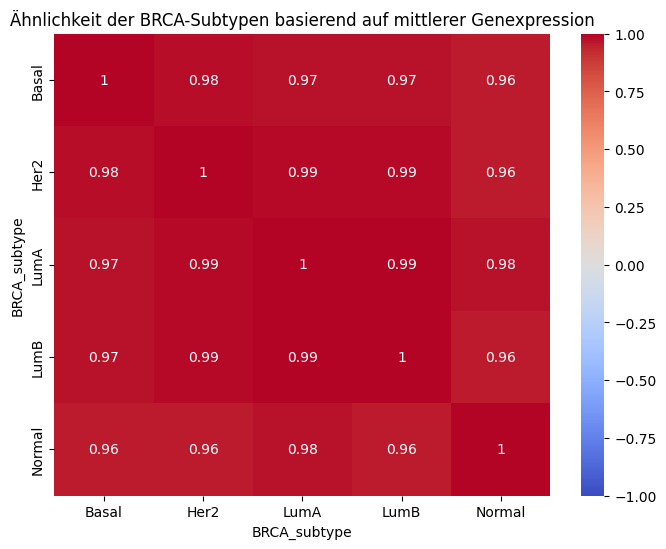

In [30]:
#visuell darstellen
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(subtype_similarity, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Ähnlichkeit der BRCA-Subtypen basierend auf mittlerer Genexpression")
plt.show()

In [32]:
#Top 10 oder Top 20 variabelsten Gene nehmen
gene_cols = [
    c for c in combined_labeled.columns
    if c not in ["BRCA_subtype", "top_gene", "top_gene_value"]
]

gene_diff = (
    combined_labeled.groupby("BRCA_subtype")[gene_cols]
    .mean()
    .T
    .var(axis=1)
    .sort_values(ascending=False)
)

top20_genes = gene_diff.head(20).index.tolist()

subtype_means_top20 = combined_labeled.groupby("BRCA_subtype")[top20_genes].mean()
print(subtype_means_top20)

                   AGR3      SOX10      GABRP      ADH1B      MUCL1  \
BRCA_subtype                                                          
Basal          2.134499   9.219970  12.706856   5.008237   4.684851   
Her2           5.576449   3.034076   6.156882   5.519861  11.404355   
LumA          10.895670   5.388394   7.283446   8.181329   7.183686   
LumB          10.763942   2.724136   5.096420   5.601706   6.025591   
Normal         7.928340  10.413892  12.050644  12.947375  11.733540   

                  SFRP1       ESR1     ROPN1     ADIPOQ      STAC2       AGR2  \
BRCA_subtype                                                                    
Basal         12.987384   6.503725  7.672660   4.884540   9.160935   5.688866   
Her2           8.084070   8.309304  1.425245   5.415342   6.918510  11.815663   
LumA           9.391715  13.395657  1.882279   7.812400   5.836523  12.779882   
LumB           6.777895  13.600336  0.973649   5.687856   3.100661  13.010132   
Normal        14

In [33]:
numeric_cols = combined_labeled.select_dtypes(include=["number"]).columns

gene_diff = (
    combined_labeled.groupby("BRCA_subtype")[numeric_cols]
    .mean()
    .T
    .var(axis=1)
    .sort_values(ascending=False)
)

top20_genes = gene_diff.head(20).index.tolist()

subtype_means_top20 = combined_labeled.groupby("BRCA_subtype")[top20_genes].mean()
print(subtype_means_top20)

                   AGR3      SOX10      GABRP      ADH1B      MUCL1  \
BRCA_subtype                                                          
Basal          2.134499   9.219970  12.706856   5.008237   4.684851   
Her2           5.576449   3.034076   6.156882   5.519861  11.404355   
LumA          10.895670   5.388394   7.283446   8.181329   7.183686   
LumB          10.763942   2.724136   5.096420   5.601706   6.025591   
Normal         7.928340  10.413892  12.050644  12.947375  11.733540   

                  SFRP1       ESR1     ROPN1     ADIPOQ      STAC2       AGR2  \
BRCA_subtype                                                                    
Basal         12.987384   6.503725  7.672660   4.884540   9.160935   5.688866   
Her2           8.084070   8.309304  1.425245   5.415342   6.918510  11.815663   
LumA           9.391715  13.395657  1.882279   7.812400   5.836523  12.779882   
LumB           6.777895  13.600336  0.973649   5.687856   3.100661  13.010132   
Normal        14

In [34]:
print(combined_labeled.dtypes.tail(10))

MED15             float64
ZIC5              float64
MED16             float64
HCG27             float64
CYP2A13           float64
CCR10             float64
KDM4D             float64
BRCA_subtype          str
top_gene              str
top_gene_value    float64
dtype: object


In [35]:
combined.isna()

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,WT1,RNF24,MED15,ZIC5,MED16,HCG27,CYP2A13,CCR10,KDM4D,BRCA_subtype
TCGA-AR-A5QQ-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
TCGA-D8-A1JA-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-BH-A0BQ-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-BH-A0BT-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-A8-A06X-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-A2-A3XT-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
TCGA-B6-A0X7-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-BH-A1EV-11,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TCGA-3C-AALJ-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [38]:
combined.isna().sum(axis=1)

TCGA-AR-A5QQ-01    1
TCGA-D8-A1JA-01    0
TCGA-BH-A0BQ-01    0
TCGA-BH-A0BT-01    0
TCGA-A8-A06X-01    0
                  ..
TCGA-A2-A3XT-01    1
TCGA-B6-A0X7-01    0
TCGA-BH-A1EV-11    0
TCGA-3C-AALJ-01    1
TCGA-B6-A0X1-01    0
Length: 1218, dtype: int64

In [ ]:
#missing values in this dataset
combined.isna().sum(axis=1).sum()

np.int64(275)

In [40]:
combined.isna().any(axis=1).any()

np.True_

In [41]:
combined.to_csv("Combined_dataset_outcome.csv")

In [42]:
#Nan im Subtyp entfernen
combined_clean=combined.dropna(subset=["BRCA_subtype"]).copy()

In [ ]:
#alle Nans entfernen
combined_clean_critical=combined.dropna().copy()